## 1 Gerade durch zwei experimentelle Messungen und Fehler

Am Mittwoch werden Sie lernen, wie man eine Gerade an beliebig viele Messungen anpasst.
Für die Übungen zur Fehlerrechnung betrachten wir nun den Fall mit zwei Messwerten, der eine analytische Lösung hat. Wir benutzen dabei das gestriege Beispiel der Stromstärkemessungen und verwenden nur die erste und die letzte Messung ($U_1,I_1$) und ($U_{10}, I_{10}$).

Die Gerade ist dann $I_i = m U_i + a$.

Mit $m = \frac{I_{10} - I_1}{U_{10}-U_1}$ und $a= I_1 - \frac{I_{10} - I_1}{U_{10}-U_1} U_1$.

[]

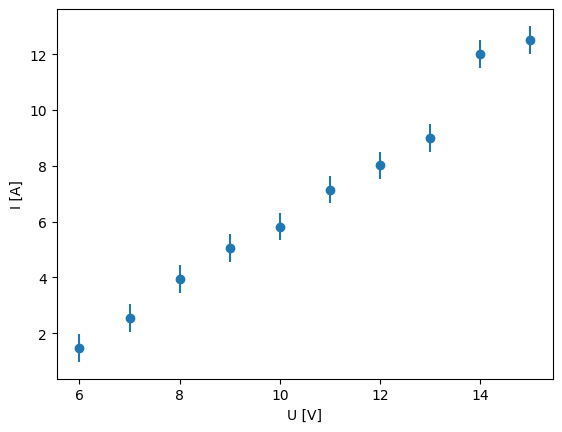

In [75]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
U = np.arange(6,15.4,1)
mus = 1.2*(U-5)
Ierr = 0.5
I = stats.norm.rvs(mus, Ierr)
plt.errorbar(U, I,yerr=Ierr, fmt='o')
plt.xlabel("U [V]")
plt.ylabel("I [A]")
plt.plot()

### 1.1 Steigung und Achsenabschnitt
Berechnen Sie $m$ und $a$. 
Zeichnen Sie als Test Ihre Gerade ein. Geht die Gerade exakt durch den ersten und letzten Messpunkt?

[]

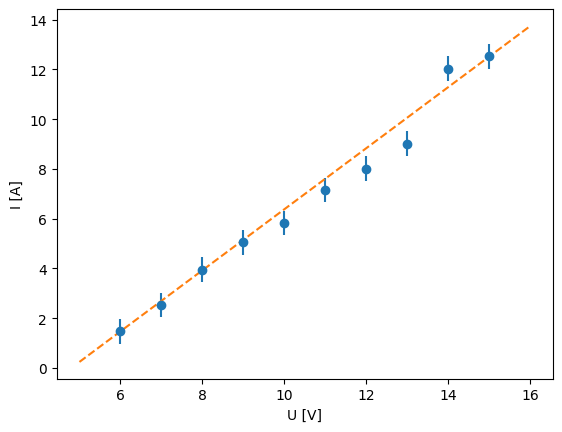

In [76]:
m=(I[9] - I[0])/(U[9]-U[0])
a=I[0]- (I[9] - I[0])/(U[9]-U[0]) * U[0]

Us = np.linspace(5,16,100)
plt.errorbar(U, I,yerr=Ierr, fmt='o')
plt.plot(Us, m*Us+a,ls='--')
plt.xlabel("U [V]")
plt.ylabel("I [A]")
plt.plot()

### 1.2 Fehlerrechnung
Berechnen Sie nun mit Fehlerfortpflanzung jeweils den Fehler auf die Steigung $m$ und den Achsenabschnitt $a$.

Führen Sie Variablen für $\frac{dm}{dI_1}, \frac{dm}{dI_{10}} \frac{da}{dI_1}$ und  $\frac{da}{dI_{10}}$ ein und geben Sie die Werte der Ableitungen und die endgültigen Fehler aus.

In [77]:
dmdI1  = -1/(U[9]-U[0])
dmdI10 = 1/(U[9]-U[0])
dadI1  = 1+1/(U[9]-U[0])*U[0]
dadI10 = -1/(U[9]-U[0])*U[0]

merr = np.sqrt(dmdI1*Ierr*dmdI1*Ierr + (dmdI10*Ierr)* (dmdI10*Ierr))
aerr = np.sqrt((dadI1*Ierr)**2 + (dadI10*Ierr)**2)
print(f"Steigung m={m} +- {merr}")
print(f"Achsenabschnitt a={a} +- {aerr}")


Steigung m=1.2271591277277547 +- 0.07856742013183861
Achsenabschnitt a=-5.890123114053082 +- 0.8975274678557505


### 1.3 Überprüfung durch Monte Carlo

Der unterstehende Code-Block simuliert $10\,000$  Stromstärkemessreihen. Berechnen Sie für jede Messreihe $i$ die Steigung $m_i$ und den Achsenabschnitt $a_i$. 
Zeichnen Sie je ein Histogramm für die Steigungen und Achsenabschnitte der $10\,000$ Stromstärkemessreihen

Vergleichen Sie die Standardabweichungen der Steigungs- und Achsenabschnittstichproben mit den berechneten Fehlern aus 1.2.

Stimmen die Werte überein?

In [78]:
ngen=10000
mus_gen = np.repeat(mus, ngen).reshape((-1,ngen))
I_sample = stats.norm.rvs(mus_gen, Ierr)
I_sample

array([[ 0.36902877,  1.82522127,  1.17348891, ...,  0.70502155,
         1.31596949,  0.56349053],
       [ 3.11600385,  1.58288222,  1.81968221, ...,  1.89114342,
         2.7417977 ,  1.22874161],
       [ 3.86143217,  2.7093368 ,  3.68145839, ...,  3.44211584,
         4.40738354,  3.94964448],
       ...,
       [10.34302254,  9.19976069,  9.95765352, ...,  9.80993699,
         9.46724795,  9.23041091],
       [10.8947417 , 10.35744305, 10.21018397, ..., 11.08043778,
        10.07907187, 10.83940926],
       [11.53926518, 12.21194267, 12.58955554, ..., 12.37942499,
        12.50324768, 12.7539989 ]])

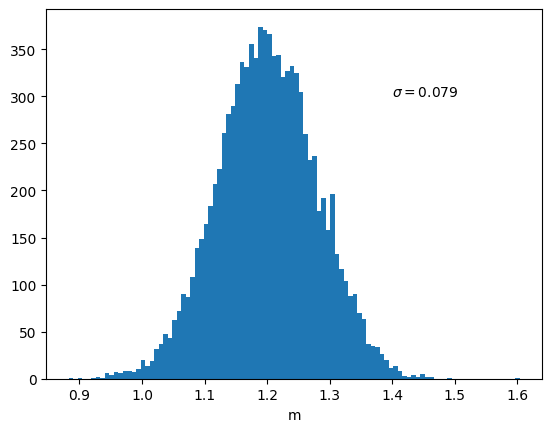

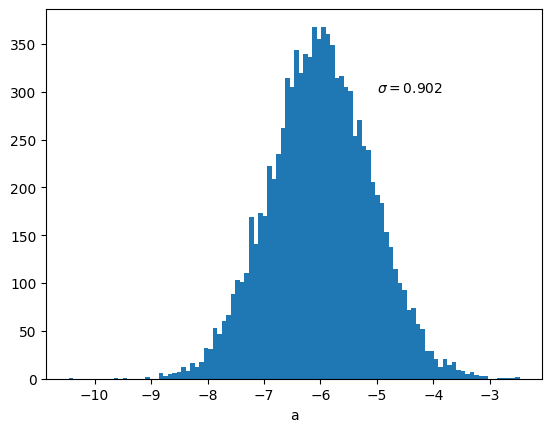

Fehler auf m  berechnet 0.079 aus MC 0.079
Fehler auf a  berechnet 0.898 aus MC 0.902


In [79]:
m_sample=(I_sample[9,:] - I_sample[0,:])/(U[9]-U[0])
a_sample=I_sample[0,:]- (I_sample[9,:] - I_sample[0,:])/(U[9]-U[0]) * U[0]
plt.hist(m_sample, bins=100)
plt.text(1.4,300,f"$\\sigma={np.std(m_sample, ddof=1):0.3f}$")
plt.xlabel("m")
plt.show()
plt.hist(a_sample, bins=100)
plt.text(-5,300,f"$\\sigma={np.std(a_sample, ddof=1):0.3f}$")
plt.xlabel("a")
plt.show()
print(f"Fehler auf m  berechnet {merr:0.3f} aus MC {np.std(m_sample, ddof=1):0.3f}")
print(f"Fehler auf a  berechnet {aerr:0.3f} aus MC {np.std(a_sample, ddof=1):0.3f}")

# 1.4 Fehlerrechnung 2

Berechnen Sie nun für  die in 1.1 gefundene Gerade die Funktionswerte bei U=6 V, 10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die schon berechneten Fehler auf $m$ und $a$ fortpflanzen. Schreiben Sie dafür je eine Funktion, für die Geradenwerte und eine für die Fehler. 
```
def func(U, m, a):
    return m*U +a

def func_err(U, merr, aerr):
    dfdm = 
    dfda = 
    return np.sqrt(dfdm*dfdm*merr*merr + dfda*dfda*aerr*aerr)
```


Ergeben diese Werte Sinn? Welche Fehler würden Sie für die Messstellen 6 V und 15 V erwarten?

In [80]:
def func(U, m, a):
    return m*U +a

def func_err(U, merr, aerr):
    dfdm = U
    dfda = 1
    return np.sqrt(dfdm*dfdm*merr*merr + dfda*dfda*aerr*aerr)


Utest= [6, 10, 11, 15]
for u in Utest:
    print(f"for U = {u} V: I = {func(u, m, a):0.3f}  +- {func_err(u, merr, aerr):0.3f}")

for U = 6 V: I = 1.473  +- 1.014
for U = 10 V: I = 6.381  +- 1.193
for U = 11 V: I = 7.609  +- 1.246
for U = 15 V: I = 12.517  +- 1.481


## 1.5  Überprüfung durch Monte Carlo

Überprüfen Sie wiederum die gefundenen Fehler mit den Geraden aus den $10\,000$ Messreihen.
Mit den Steigungs- und Achsenabschnittswerten ($m_i, a_i$) aus 1.3 können die Funktionswerte für jede Messreihe berechnet werden. 

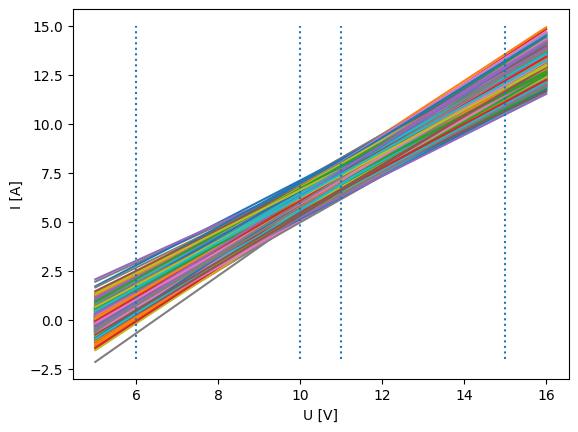

In [81]:

#plt.plot(Us,m_sample[0]*Us + a_sample[0])
#plt.plot(Us,m_sample[1]*Us + a_sample[1])
#plt.plot(Us,m_sample[2]*Us + a_sample[2])
Us = np.linspace(5,16,200)
for i in range(1000):
    plt.plot(Us,m_sample[i]*Us + a_sample[i])

plt.vlines([6,10,11,15], -2, 15, ls='dotted')
plt.xlabel("U [V]")
plt.ylabel("I [A]")

plt.show()

Berechnen Sie mit den Steigungs- und Achsenabschnittswerten ($m_i, a_i$) aus 1.3 die Stromstärkewerte bei U=6 V, 10 V, 11 V und 15 V mit $I_i(U) = m_i U + a_i$.
Zeichnen Sie die vier Histogramme der Stromstärkewerte.

Geben Sie die Standardabweichungen der vier Verteilungen aus.


Was beobachten Sie?

for U = 6 V: sigma=0.5015239896956681
for U = 10 V: sigma=0.35598959362076993
for U = 11 V: sigma=0.3560552015897974
for U = 15 V: sigma=0.5019429793871952


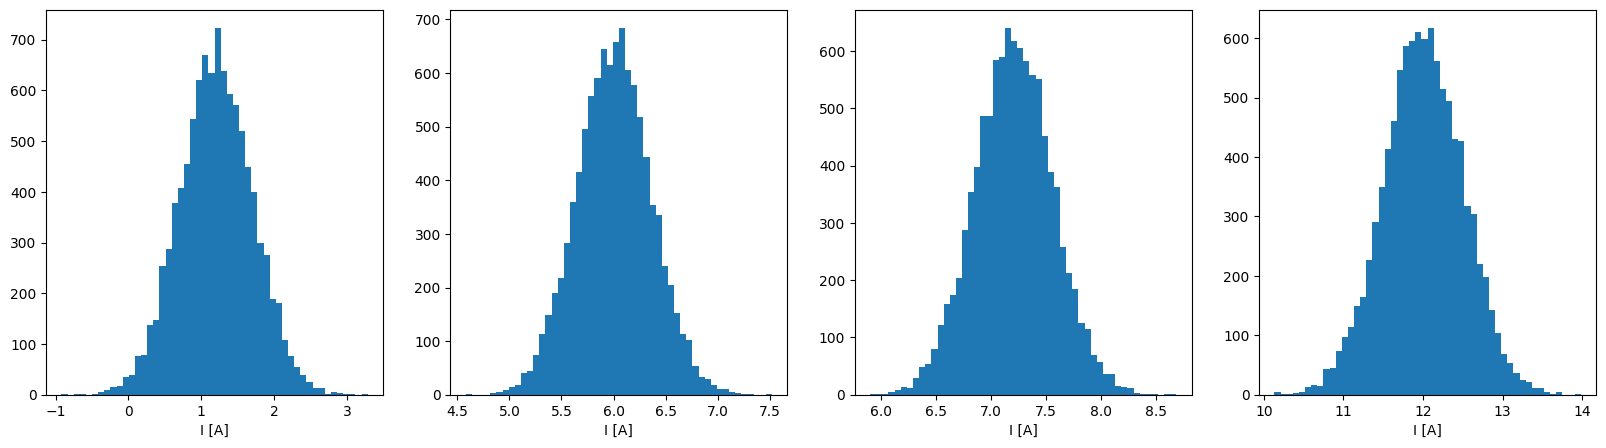

In [82]:
fig,axes = plt.subplots(1,4,figsize=(20,5))

for i,u in enumerate(Utest):
    axes[i].hist(m_sample*u+a_sample, bins=50)
    axes[i].set_xlabel("I [A]")
    print(f"for U = {u} V: sigma={np.std(m_sample*u+a_sample)}")



## 2 Alternative Geradenparametrisierung

Entwickeln Sie nun die Gerade um den Schwerpunkt (Mittelwert) $\hat U$ der Spannungswerte, an denen gemessen wurde.


Also: $I(U) = m (U-\hat U) + b$

Die Konstante $b$ ist nun nicht mehr der Achsenabschnitt, sondern der Funktionswert bei $U=\hat U$.

Die Formel für die Steigung $m$ ändert sich nicht und der Parameter $b$ ist dann mit $\hat U = \frac{U_1 + U_{10}}{2} = 25{,}5$ V:

$ b = I_1 - \frac{I_{10} - I_1}{U_{10}-U_1} (U_1 - \hat U)  =  I_1 - \frac{(I_{10} - I_1)(2U_1 - U_{1} - U{10})}{2(U_{10}-U_1)} = I_1 - \frac{(I_{10} - I_1)(U_{1} - U_{10})}{2(U_{10}-U_1)} =  I_1 + \frac{I_{10} - I_1}{2} = \frac{I_1 + I_{10}}{2}= \hat I$

#### 2.1 Parameterberechnung
Berechnen Sie $b$ und zeichnen Sie die Gerade in die Daten ein.

[]

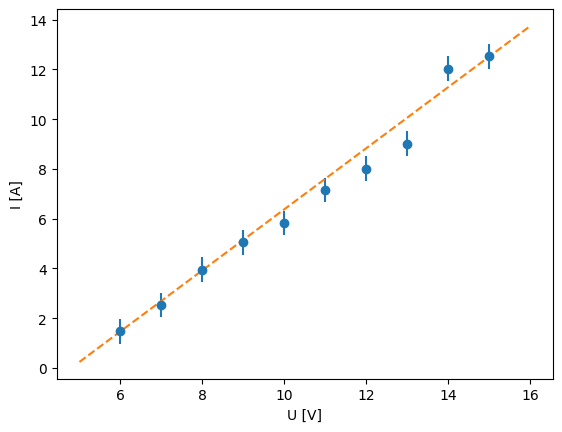

In [83]:
Umid = (U[0]+U[9])/2 
b = I[0] - (I[9] - I[0])/(U[9]-U[0]) * (U[0]-Umid)

plt.errorbar(U, I,yerr=Ierr, fmt='o')
plt.plot(Us, m*(Us-Umid)+b,ls='--')
plt.xlabel("U [V]")
plt.ylabel("I [A]")
plt.plot()

### 2.2 Fehlerrechnung
Berechnen Sie nun mit Fehlerfortpflanzung jeweils den Fehler auf die Steigung $m$ und den Parameter $b$.

Führen Sie Variablen für $\frac{dm}{dI_1}, \frac{dm}{dI_{10}} \frac{db}{dI_1}$ und  $\frac{db}{dI_{10}}$ ein und geben Sie die Werte der Ableitungen und die endgültigen Fehler aus.

In [84]:
dmdI1  = -1/(U[9]-U[0])
dmdI10 = 1/(U[9]-U[0])
dbdI1  = 1+1/(U[9]-U[0])*(U[0]-Umid)
dbdI10 = -1/(U[9]-U[0])*(U[0] - Umid)

berr = np.sqrt((dbdI1*Ierr)**2+(dbdI10*Ierr)**2)
print(f"Steigung m={m} +- {merr}")
print(f"Abschnitt b={b} +- {berr}")

Steigung m=1.2271591277277547 +- 0.07856742013183861
Abschnitt b=6.995047727088342 +- 0.3535533905932738


### 2.3 Überprüfung durch Monte Carlo

Benutzen Sie die selben simulierten 10 000 Stromstärkemessreihen aus Aufgabe 1. Berechnen Sie für jede Messreihe die Steigung und den Funktionswert im Schwerpunkt $b$. Vergleichen Sie die Standardabweichungen der $m$- und $b$-Stichproben mit den berechneten Fehlern aus 2.2.

Stimmen die Werte überein?

In [85]:
b_sample = I_sample[0,:] - (I_sample[9,:] - I_sample[0,:])/(U[9]-U[0]) * (U[0]-Umid)

print(f"Fehler auf b aus MC:{np.std(b_sample,ddof=1):0.3f}")

Fehler auf b aus MC:0.354


### 2.4 Fehlerrechnung 2

Berechnen Sie nun für  die in 2.1 gefundene Gerade die Funktionswerte bei U=6 V, 10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die schon berechneten Fehler auf $m$ und $a$ fortpflanzen. Schreiben Sie dafür je eine Funktion, für die Geradenwerte und eine für die Fehler. 
```
def func2(U, m, b):
    return m*(U-Uhat) +b

def func2_err(U, merr, berr):
    dfdm = 
    dfdb = 
    return np.sqrt(dfdm*dfdm*merr*merr + dfdb*dfdb*berr*berr)
```


Ergeben diese Werte Sinn?

In [86]:
def func2(U, m, b):
    return m*(U-Umid) +b

def func2_err(U, merr, berr):
    dfdm = U-Umid
    dfdb = 1
    return np.sqrt(dfdm*dfdm*merr*merr + dfdb*dfdb*berr*berr)

for u in Utest:
    print(f"for U = {u} V: I = {func2(u, m, b):0.3f}  +- {func2_err(u, merr, berr):0.3f}")

for U = 6 V: I = 1.473  +- 0.500
for U = 10 V: I = 6.381  +- 0.356
for U = 11 V: I = 7.609  +- 0.356
for U = 15 V: I = 12.517  +- 0.500


## 2.5  Überprüfung durch Monte Carlo

Überprüfen Sie wiederum die gefundenen Fehler mit den $b$- und $m$-Werte aus der Simulation in 2.3.

Was beobachten Sie?

for U = 6 V: sigma=0.5015239896956681
for U = 10 V: sigma=0.35598959362076993
for U = 11 V: sigma=0.3560552015897974
for U = 15 V: sigma=0.5019429793871952


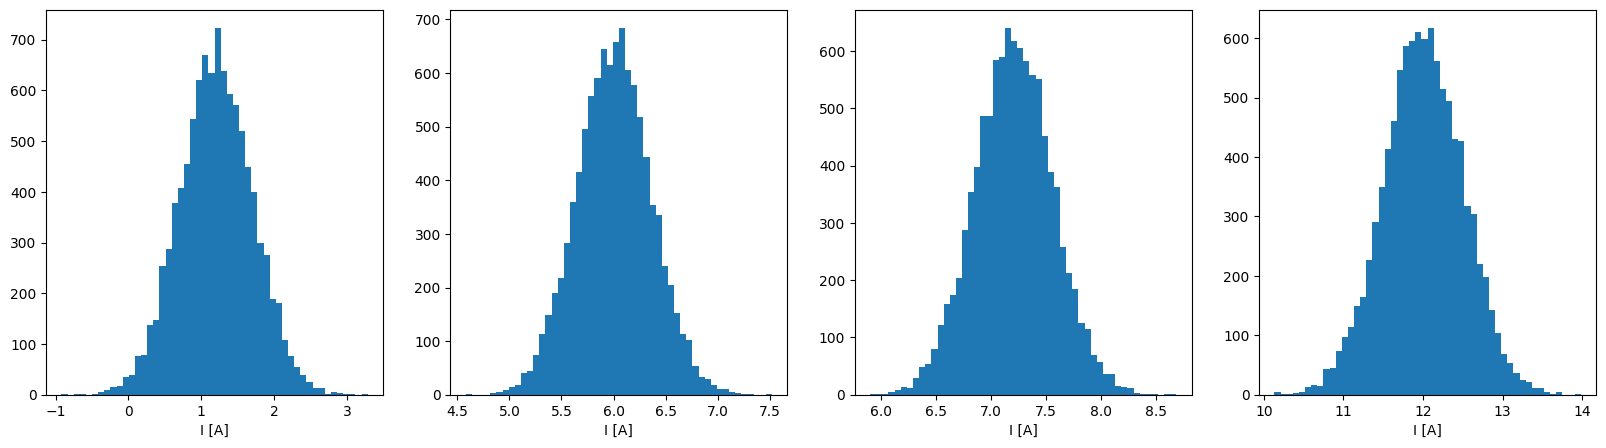

In [87]:
fig,axes = plt.subplots(1,4,figsize=(20,5))

for i,u in enumerate(Utest):
    axes[i].hist(m_sample*(u-Umid)+b_sample, bins=50)
    axes[i].set_xlabel("I [A]")
    print(f"for U = {u} V: sigma={np.std(m_sample*(u-Umid)+b_sample)}")

## 2.6 
Wie kommt es zu er dramatischen Diskrepanz im Vergleich zur anderen Parametrisierung?
Welche Methode ist also zu wählen?

**Slides**

## 3 Volle Fehlerfortpflanzung

Wir betrachten nun wieder das Beispiel aus Aufgabe 1. 


### 3.1 Kovarianzmatrix der Messungen

#### 3.1.1 Grafische Darstellung

Erstellen Sie ein 2d-Histogram der $I_1$- und $I_{10}$-Werte der 10 000 Messreihen. 

Benutzen Sie `np.hist2d`. Probieren Sie auch die Optionen `cmap=plt.cm.rainbow, cmin=1`und rufen Sie für die $z$-Achsenskala `np.colorbar()` auf.

Woran erkennen Sie, ob die Daten korreliert sind? 


ValueError: x and y must have the same length.

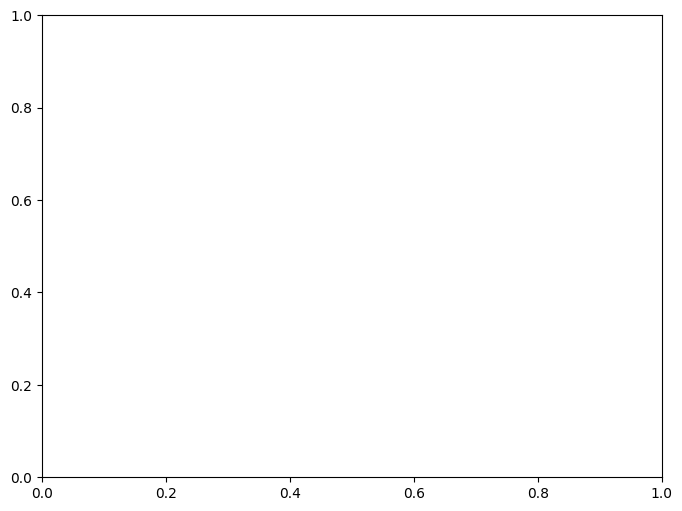

In [88]:
# Annahme: I_sample enthält die 10.000 Messreihen (Zeilen: Spannungen, Spalten: Simulationen)
I1 = I_sample
I10 = I_sample[5]

plt.figure(figsize=(8, 6))
plt.hist2d(I1, I10, bins=50, cmap=plt.cm.rainbow, cmin=1)
plt.colorbar(label='Häufigkeit')
plt.xlabel('$I_1$ [A]')
plt.ylabel('$I_{10}$ [A]')
plt.title('2D-Histogramm von $I_1$ und $I_{10}$')
plt.show()

#### 3.1.2 Varianzen und Kovarianz

Berechnen Sie für die $I_1$- und $I_{10}$-Werte der 10 000 Messreihen die Varianzen von $I_{1}$ und $I_{10}$ und die Kovarianz $\text{Cov}(I_1,I_{10})$. Benutzen Sie die Formeln von Folie 18 und im zweiten Schritt die `Numpy`-Funktionen `np.var` und `np.cov`.


Berechnen Sie auch den Korrelationskoeffizienten: $\rho_{I_1, I_{10} } = \frac{\text{Cov}(I_{1},I_{10})}{\sigma_1\sigma_{10}}$


In [89]:
var_I1 = np.var(I1)
var_I10 = np.var(I10)

cov_matrix = np.cov(I1, I10)
covariance = cov_matrix[2]

sigma_1 = np.std(I1)
sigma_10 = np.std(I10)
rho = covariance / (sigma_1 * sigma_10)

print(f"Varianz I1: {var_I1:.4f}")
print(f"Varianz I10: {var_I10:.4f}")
print(f"Kovarianz: {covariance:.4f}")
print(f"Korrelationskoeffizient (rho): {rho:.4f}")

Varianz I1: 12.1311
Varianz I10: 0.2574


TypeError: unsupported format string passed to numpy.ndarray.__format__

### 3.2 Fehlerfortpflanzug

Berechnen Sie nun mit Fehlerfortpflanzung jeweils den Fehler auf die Steigung $m$ und den Parameter $a$. Benutzen Sie die Varianzen und Kovarianz aus Aufgabe  3.1 als Messfehler auf die Stromstärke.

Benutzen Sie wieder die Variablen für $\frac{dm}{dI_1}, \frac{dm}{dI_{10}} \frac{da}{dI_1}$ und  $\frac{da}{dI_{10}}$ und geben Sie die Fehler aus.

Ändern sich die Ergebnisse verglichen mit Aufgabe 1.2?

In [ ]:
merr = np.sqrt(dmdI1*Ierr*dmdI1*Ierr + (dmdI10*Ierr)* (dmdI10*Ierr))
aerr = np.sqrt((dadI1*Ierr)**2 + (dadI10*Ierr)**2)
print(f"Steigung m={m} +- {merr}")
print(f"Achsenabschnitt a={a} +- {aerr}")


'''# Ableitungen aus 1.2 (Beispielrechnung)
deltaU = U[5] - U
dmdI1 = -1 / deltaU
dmdI10 = 1 / deltaU
dadI1 = U[5] / deltaU
dadI10 = -U / deltaU

# Volle Fehlerfortpflanzung für m
merr_full = np.sqrt( (dmdI1**2 * var_I1) + (dmdI10**2 * var_I10) + 
                     (2 * dmdI1 * dmdI10 * covariance) )

# Volle Fehlerfortpflanzung für a
aerr_full = np.sqrt( (dadI1**2 * var_I1) + (dadI10**2 * var_I10) + 
                     (2 * dadI1 * dadI10 * covariance) )

print(f"Fehler auf m (voll): {merr_full:.4f}")
print(f"Fehler auf a (voll): {aerr_full:.4f}")'''

### 3.3 Kovarianz von Steigung und Achsenabschnitt

#### 3.3.1 Grafische Darstellung

Erstellen Sie ein 2d-Histogram der $m, a$-Werte. Woran erkennen Sie, dass die Daten korreliert sind? 

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [1., 0., 0., ..., 0., 0., 0.]]),
 array([0.88274072, 0.889947  , 0.89715327, 0.90435955, 0.91156583,
        0.91877211, 0.92597838, 0.93318466, 0.94039094, 0.94759722,
        0.95480349, 0.96200977, 0.96921605, 0.97642233, 0.9836286 ,
        0.99083488, 0.99804116, 1.00524744, 1.01245371, 1.01965999,
        1.02686627, 1.03407254, 1.04127882, 1.0484851 , 1.05569138,
        1.06289765, 1.07010393, 1.07731021, 1.08451649, 1.09172276,
        1.09892904, 1.10613532, 1.1133416 , 1.12054787, 1.12775415,
        1.13496043, 1.14216671, 1.14937298, 1.15657926, 1.16378554,
        1.17099181, 1.17819809, 1.18540437, 1.19261065, 1.19981692,
        1.2070232 , 1.21422948, 1.22143576, 1.22864203, 1.23584831,
        1.24305459, 1.25026087, 1.25746714, 1.26467342, 1.2718797 ,
   

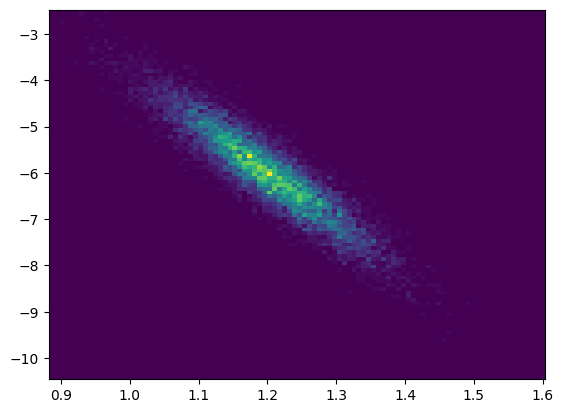

In [90]:
plt.hist2d(m_sample,a_sample, bins=100)

#### 3.3.2 Varianz und Kovarianz
Bestimmen Sie nun die Kovarianz zwischen Steigung und Achsenabschnitt $V_{ma}$ aus den Stichproben für die Steigungen und Achsenabschnitte aus Aufgabe 1.3. 


Bestimmen Sie die Kovarianzmatrix $V$ mit `np.cov`. 
Berechnen Sie aus der Matrix die Standardabweichungen für $m$ und $a$, den Kovarianzterm und den Korrelationskoeffizienten $\rho_{ma} = \frac{V_{ma}}{\sigma_m\sigma_a}$ und geben Sie die Werte aus.

In [91]:
V_ma=np.cov(m_sample,a_sample)
print(V_ma, np.corrcoef(m_sample,a_sample))

[[ 0.00624985 -0.06560011]
 [-0.06560011  0.81375802]] [[ 1.         -0.91986051]
 [-0.91986051  1.        ]]


### 3.4 Fehlerrechnung 2

Berechnen Sie nun für die in 1.1 gefundene Gerade die Funktionswerte bei U=6 V, 10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die schon berechneten Fehler mit $\sigma_m$, $\sigma_a$ und $\sigma^2_{ma}$ fortpflanzen. Schreiben Sie dafür eine neue Funktion für die Fehler und vergleichen Sie es mit den vorherigen Werten.
```
def func_err_full(U, merr, aerr, cov_ma):
    dfdm = 
    dfda = 
    return ...
```


Ergeben diese Werte Sinn? Vergleichen Sie die Werte mit dem Stichprobentest aus Aufgabe 1.5.

In [92]:
def func_err(U, V):
    dfdm = U
    dfda = 1
    return np.sqrt(dfdm*dfdm*V[0,0] + dfda*dfda*V[1,0])


Utest= [6, 10, 11, 15]
for u in Utest:
    print(f"for U = {u} V: I = {func(u,m,a):0.3f}  +- {func_err(u,V_ma):0.3f}")

for U = 6 V: I = 1.473  +- 0.399
for U = 10 V: I = 6.381  +- 0.748
for U = 11 V: I = 7.609  +- 0.831
for U = 15 V: I = 12.517  +- 1.158


### 3.5 Kovarianzmatrix der alternativen Parametrisierung

Bei der alternative Geradenparametrisierung hat auch die (vereinfachte) Fehlerrechnung die richtigen Werte geliefert. Warum ist das so?

Stellen Sie die $m$- und $b$-Werte aus dem Monte-Carlo-Test in Aufgabe 2.5 grafisch da und geben Sie deren Varianzen und Kovarianz aus, um die Frage zu beantworten.



<function matplotlib.pyplot.show(close=None, block=None)>

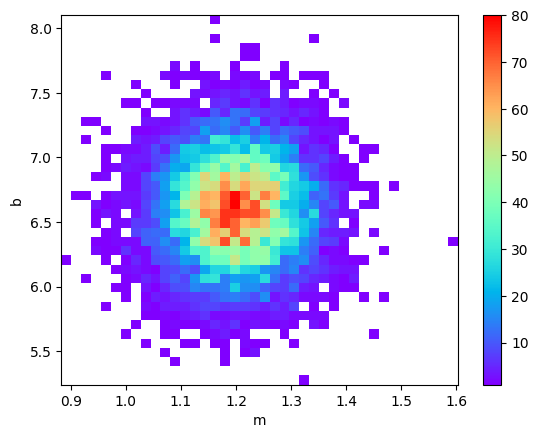

In [93]:
plt.hist2d(m_sample,b_sample, bins=(40,40),cmap=plt.cm.rainbow,cmin=1)
plt.colorbar()
plt.xlabel("m")
plt.ylabel("b")
plt.show



**Folien**

## 4 Transformation der Kovarianzmatrix

Bisher konnten wir nur die Fehler auf $a$ und $m$ ausrechnen, aber nicht die deren volle Kovarianzmatrix.
Mit dem Wissen der letzten Folien ist dies nun möglich.

### 4.1 Kovarianzmatrix für Steigung und Achsenabschnitt

Für die Berechnung der Kovarianzmatrix der Steigung und des Achsenabschnitts $V(m,a)$ muss die Kovarianzmatrix der beiden Messungen $V(I_1, I_{10})$ transformiert werden.

$$ V(m,a) = B V(I_1, I_{10}) B^T\text{, mit }B=\left( \begin{array}{cc}  \frac{dm}{dI_1}& \frac{dm}{dI_{10}}\\ \frac{da}{dI_1} &  \frac{da}{dI_{10}} \end{array} \right) $$

Mit `numpy` können Sie Matrizen auch einfach mit `np.array`definieren:
```
V_II =  np.array([[Ierr*Ierr, 0],
                  [   0, Ierr*Ierr]])
```
In `numpy` wird mit `*` ja eine elementweise Multiplikation ausgeführt. Die Matrixmultiplikation bekommen Sie mit dem `@`-Operator. Die Transformation wird  dann zu:
```
    V_am = B@V_II@B.T
```

Definieren Sie die Matrizen $V_{II}$ und die Matrix $B$ mit den Ableitungen auf Aufgabe 1.2 und berechnen Sie die Kovarianzmatrix $V_{am}$. Geben Sie wieder die Standardabweichungen auf $m$ und $a$ aus und den Korelationskoeffizienten. 

Vergleichen Sie die Matrix mit der über Monte Carlo gewonnenen Matrix aus Aufgabe 3.1.2.


In [94]:
V_II =  np.array([[Ierr*Ierr, 0],
                  [   0, Ierr*Ierr]])

B= np.array([[dmdI1,dmdI10],
             [dadI1,dadI10]])
V_am = B@V_II@B.T
print(V_ma)
#print(np.cov(m_sample,a_sample))

[[ 0.00624985 -0.06560011]
 [-0.06560011  0.81375802]]


### 4.2 Fehlerrechnung 2

Berechnen Sie nun für die in 1.1 gefundene Gerade die Funktionswerte bei U=6 V,  10 V, 11 V und 15 V. Berechnen Sie zusätzlich die Fehler auf diese Werte, imdem Sie die eben berechneten $V_{ma}$ transformieren. Schreiben Sie dafür eine neue Funktion für die Fehler und vergleichen Sie es mit den vorherigen Werten.
```
def func_err_mat(U, V_ma):
    dfdm = 
    dfda =
    B = np.array([,])
    return 
```


Ergeben diese Werte Sinn? Vergleichen Sie die Werte mit dem Stichprobentest aus Aufgabe 1.5.

In [95]:
def func_err_mat(U, V_ma):
    dfdm = U
    dfda = 1
    B = np.array([,])
    return 

Utest= [6, 10, 11, 15]
for u in Utest:
    print(f"for U = {u} V: I = {func(u, m, a):0.3f}  +- {func_err_mat(u, merr, aerr):0.3f}")

SyntaxError: invalid syntax (3306270241.py, line 4)

### 4.1 Kovarianzmatrix für die andere Geradenparametrisierung

Berechnen Sie nun analog die Kovarianzmatrix der alternativen Parametrisierung $V(m,b)$.



In [97]:
B2=np.array([[dmdI1,dmdI10],
             [dbdI1,dbdI10]])
V_mb= B2@V_II@B2.T
print(V_mb)

print(f"Fehler auf m: {np.sqrt(V_mb[0,0])}")
print(f"Fehler aus b: {np.sqrt(V_mb[1,1])}")

[[0.00617284 0.        ]
 [0.         0.125     ]]
Fehler auf m: 0.07856742013183861
Fehler aus b: 0.3535533905932738
